# SA 3 - K-means

## Justificación

Agrupo las observaciones de Samsung usando precio de cierre y volumen. Primero escalo las dos variables para que ninguna domine por su unidad de medida.

## Diseño del modelo

El proceso está ordenado en celdas: carga, preparación, ajuste, evaluación y guardado del modelo.

Repositorio: https://github.com/axelisaak10/evaluacion-2

In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "samsung.csv")
datos["Date"] = pd.to_datetime(datos["Date"], dayfirst=True)
datos.head()

## Optimización del número de grupos

In [ ]:
variables = datos[["Close", "Volume"]]
escala = StandardScaler()
x = escala.fit_transform(variables)

pruebas = []

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, n_init=30, random_state=42)
    grupos = modelo.fit_predict(x)
    pruebas.append({
        "k": k,
        "silhouette": silhouette_score(x, grupos),
        "calinski_harabasz": calinski_harabasz_score(x, grupos),
        "davies_bouldin": davies_bouldin_score(x, grupos),
    })

resultados = pd.DataFrame(pruebas)
resultados

In [ ]:
mejor_k = int(resultados.loc[resultados["silhouette"].idxmax(), "k"])

kmeans = KMeans(n_clusters=mejor_k, n_init=50, random_state=42)
datos["grupo"] = kmeans.fit_predict(x)
mejor_k

## Gráficas

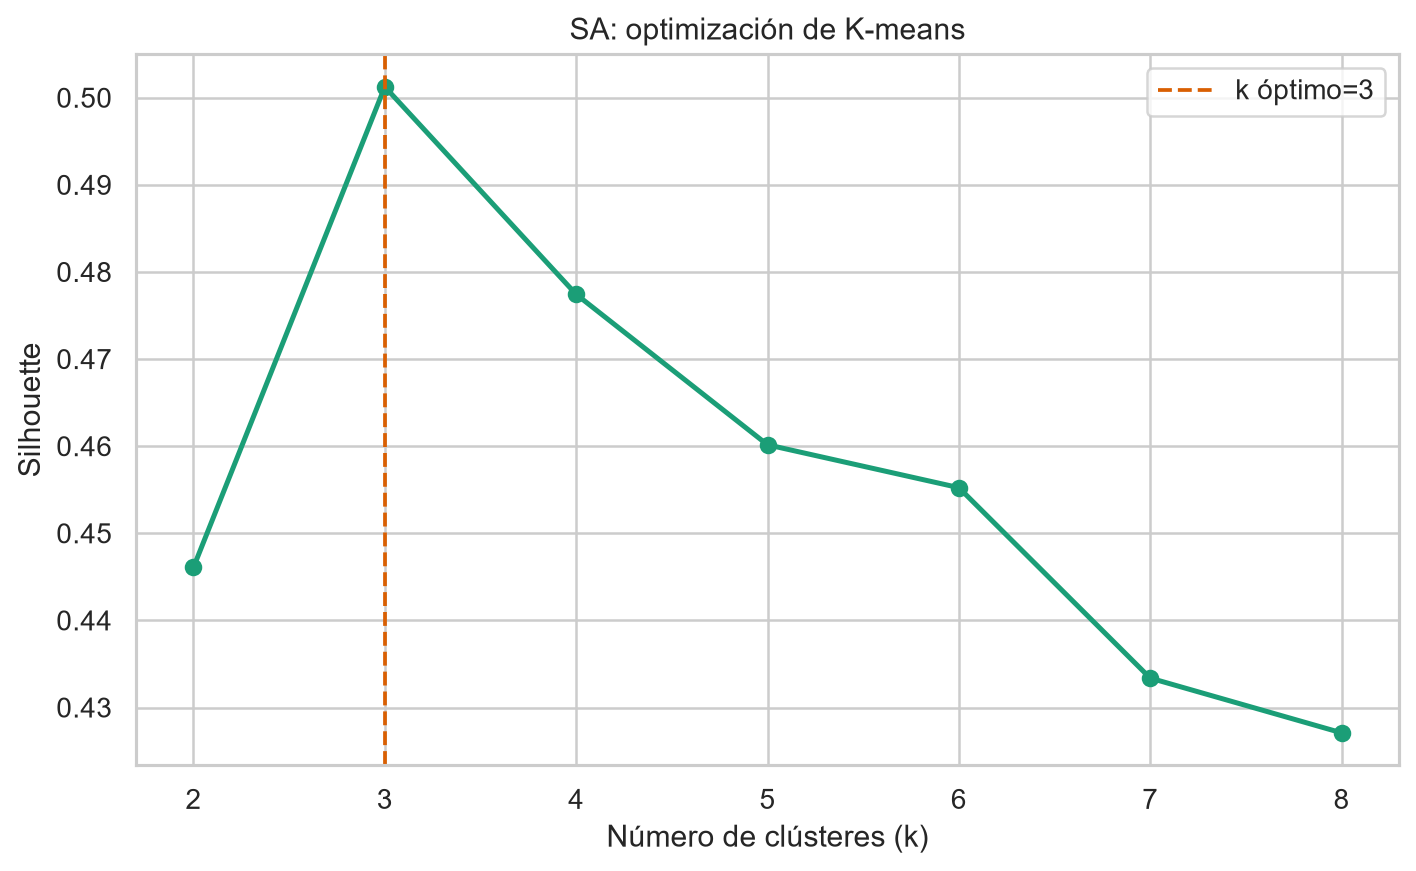

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(resultados["k"], resultados["silhouette"], "o-")
plt.axvline(mejor_k, linestyle="--", color="red")
plt.xlabel("Número de grupos")
plt.ylabel("Silhouette")
plt.title("Selección de k")
plt.show()

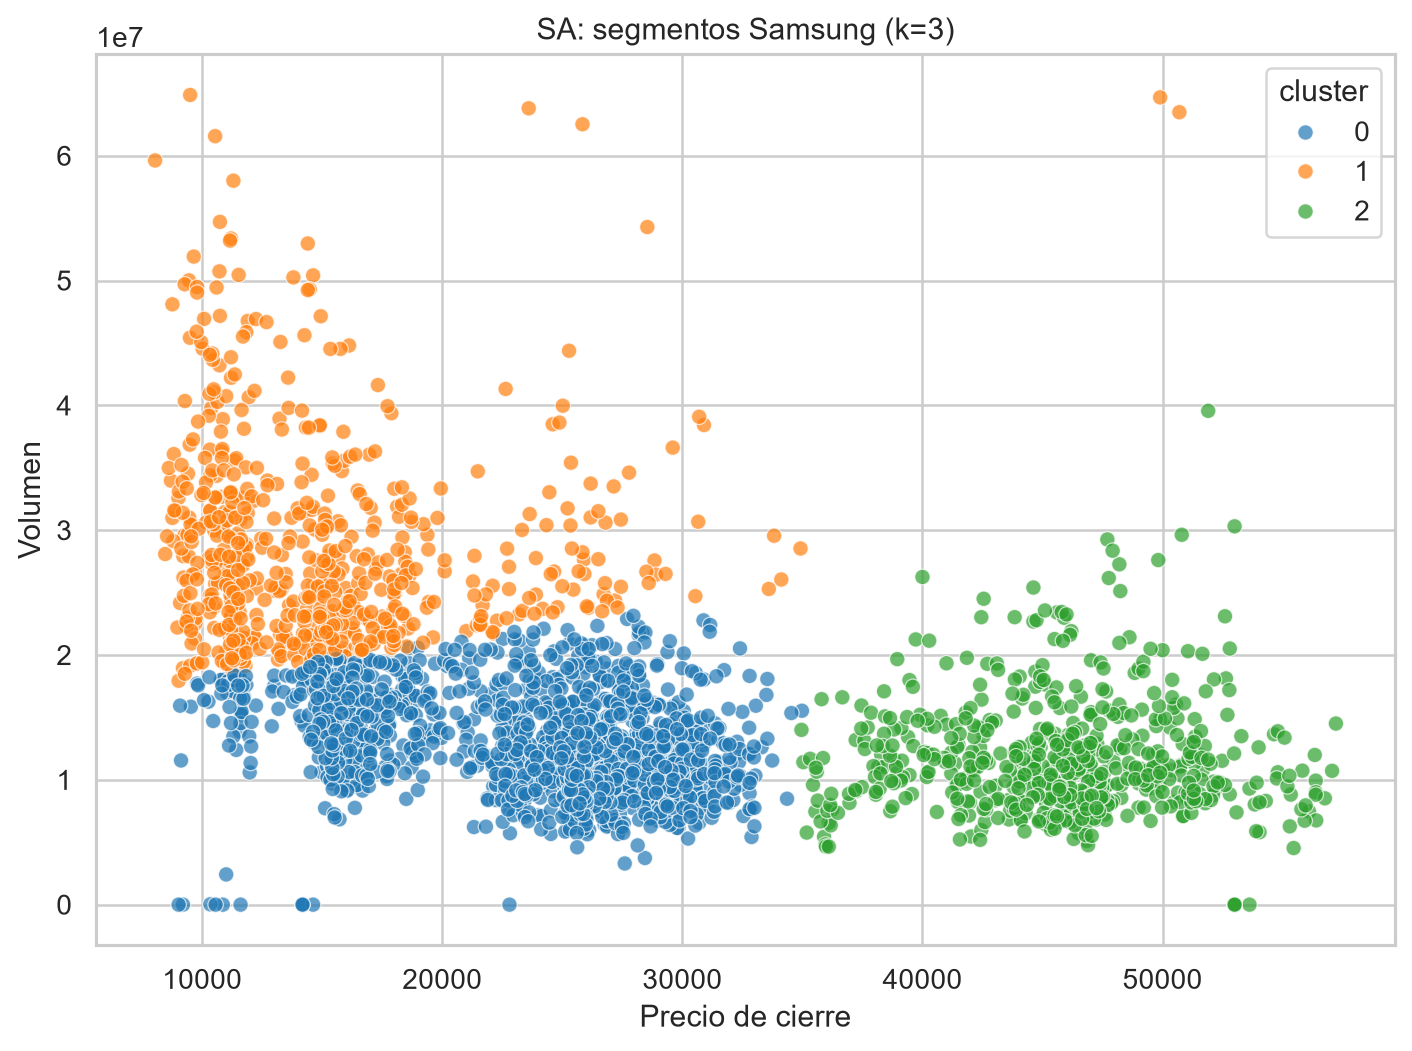

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=datos,
    x="Close",
    y="Volume",
    hue="grupo",
    palette="tab10",
    alpha=0.7,
)
plt.xlabel("Precio de cierre")
plt.ylabel("Volumen")
plt.title(f"Grupos encontrados con k={mejor_k}")
plt.show()

In [ ]:
joblib.dump(
    {"escala": escala, "modelo": kmeans},
    ruta / "models" / "sa_kmeans_samsung.joblib",
)
resultados.to_csv(ruta / "results" / "kmeans_busqueda_k.csv", index=False)

## Interpretación

El valor elegido fue `k=3` porque obtuvo el silhouette más alto. Los grupos describen combinaciones parecidas de precio y volumen; no representan categorías oficiales de mercado.